In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [2]:
G = nx.Graph()

G.add_node(2)
list(G.nodes)

[2]

In [3]:
G.add_edge(1,2)
list(G.edges)

[(2, 1)]

In [4]:
G.degree[2]

1

In [5]:
def make_graph(num_nodes, edge_prob):
    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))

    for x in range(num_nodes):
        for y in range(x + 1, num_nodes):
            if np.random.rand() < edge_prob:
                G.add_edge(x, y)

    return G

G = make_graph(10, 0.1)
print(G.nodes)
print(G.edges)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[(0, 1), (0, 5), (0, 8), (1, 2), (1, 7), (1, 9), (2, 3), (2, 4), (3, 8), (4, 6), (7, 8)]


In [6]:
max(nx.connected_components(G), key=len)

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

Text(0, 0.5, 'Size of Largest Component')

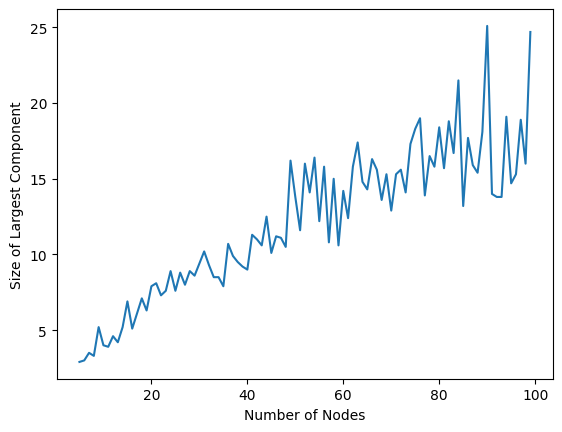

In [7]:
sizes = np.arange(5, 100, 1)
len_comp = []
for n in sizes:
    length = 0
    for i in range(10):
        G = make_graph(n, 1/n)
        length += len(max(nx.connected_components(G), key=len))
    len_comp.append(length/10)

plt.plot(sizes, len_comp)
plt.xlabel('Number of Nodes')
plt.ylabel('Size of Largest Component')

- We can see it's basically increasing linear. 

In [8]:
%%time
G = nx.erdos_renyi_graph(100, 0.5)

G.nodes()

CPU times: user 8.73 ms, sys: 1.35 ms, total: 10.1 ms
Wall time: 4.32 ms


NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99))

In [9]:
%%time
make_graph(100, 0.5)

G.nodes()

CPU times: user 14.6 ms, sys: 2.34 ms, total: 17 ms
Wall time: 8.23 ms


NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99))

# 2. Loading a Graph

In [13]:
G = nx.read_edgelist('./graph0.txt')

In [14]:
G.nodes

NodeView(('0', '1', '2', '3', '4', '5', '6'))

In [16]:
G.add_node('10')
G.add_edge('5','10')

# 3. Degree Distributions

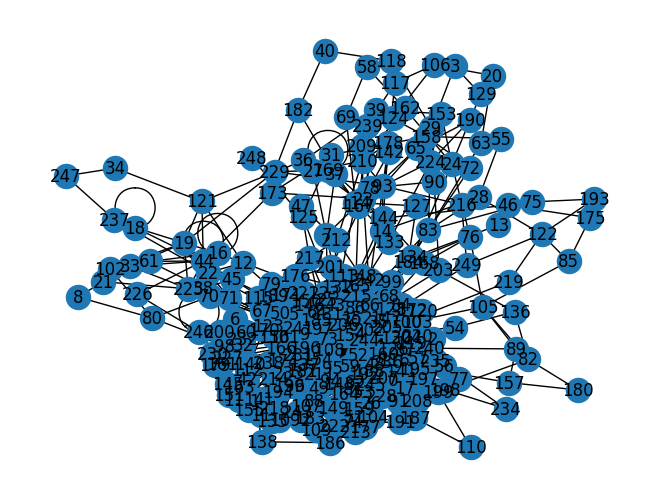

In [57]:
nx.draw(G, with_labels=True)
plt.show()

[0, 0, 60, 69, 61, 34, 5, 4, 5, 2, 3, 3, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]


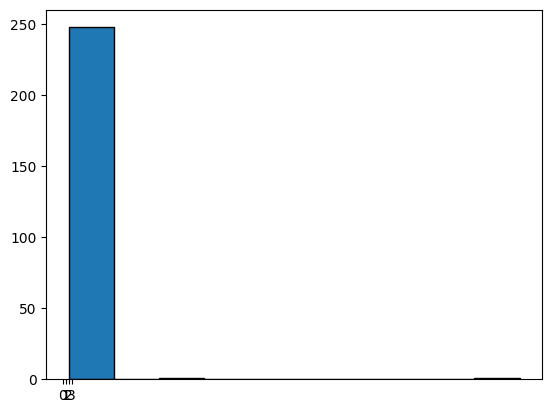

In [58]:
print(nx.degree_histogram(G))

plt.hist(dict(G.degree).values(), edgecolor='black')
plt.xticks(np.arange(0,4))
plt.show()

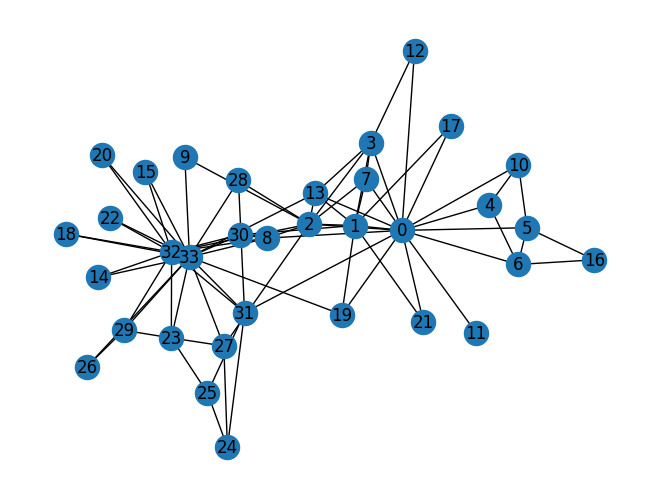

In [59]:
karate_G = nx.karate_club_graph()

nx.draw(karate_G, with_labels=True)
plt.show()

[0, 1, 11, 6, 6, 3, 2, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1]


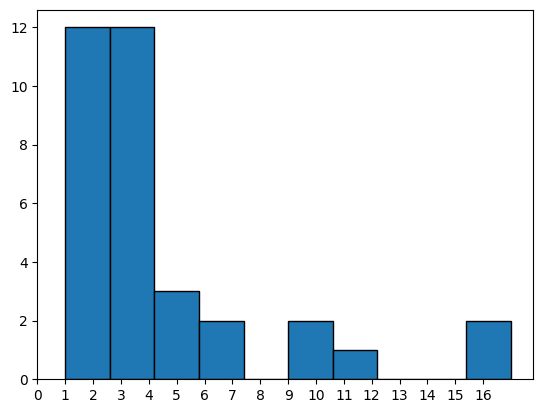

In [60]:
print(nx.degree_histogram(karate_G))

plt.hist(dict(karate_G.degree).values(), edgecolor='black')
plt.xticks(np.arange(0,max(dict(karate_G.degree).values())))
plt.show()

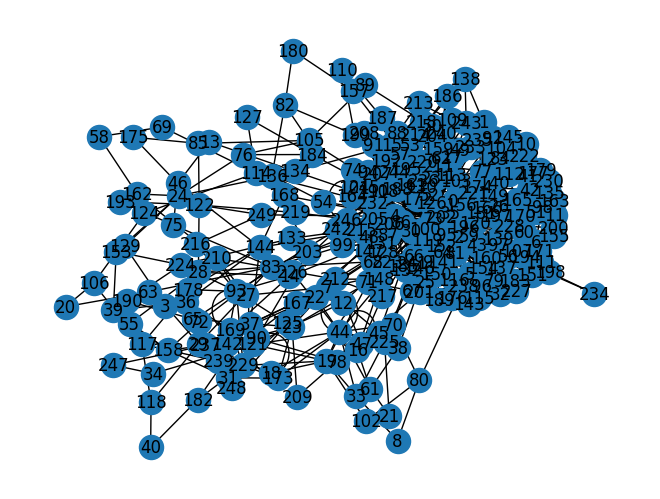

In [61]:
G = nx.LFR_benchmark_graph(250, 3, 1.5, 0.1, average_degree=5, min_community=20, seed=10)

nx.draw(G, with_labels=True)
plt.show()

[0, 0, 60, 69, 61, 34, 5, 4, 5, 2, 3, 3, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]


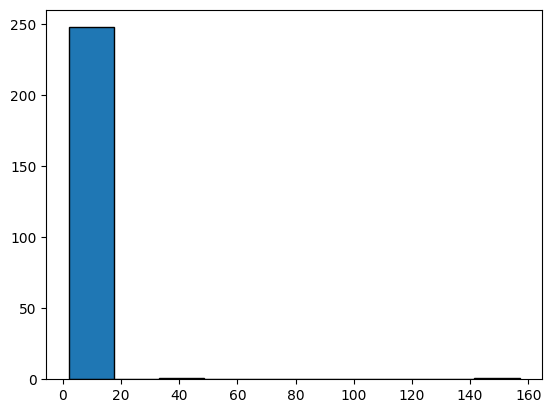

In [62]:
print(nx.degree_histogram(G))

plt.hist(dict(G.degree).values(), edgecolor='black')
# plt.xticks(np.arange(0,max(dict(G.degree).values())))
plt.show()

I notice that almost all the degree values are below 50, except for one which is around 150. This shows there is one highly connected node in the graph.

# 4. Community Detection

In [96]:
communities = nx.get_node_attributes(G, 'community')

In [102]:
def groundtruth_communities_to_labels(communities):
    groundtruth = {}

    for key, value in communities.items():
        groundtruth[key] = list(value)[-1]
    return list(groundtruth.values())

ground_truth = groundtruth_communities_to_labels(communities)

np.unique(ground_truth)

array([121, 246, 249])

In [103]:
louvain_comm = nx.community.louvain_communities(G)

In [104]:
def detected_communities_to_labels(communities, G):
    labels = [-1]*len(G)

    for i in range(len(communities)):
        for j in list(communities[i]):
            labels[j] = i

    return labels

detected_comms = detected_communities_to_labels(louvain_comm, G)
np.unique(detected_comms)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [105]:
from sklearn.metrics import normalized_mutual_info_score
normalized_mutual_info_score(ground_truth, detected_comms)

0.563414625127299

In [114]:
# Q7
community_generator = nx.community.girvan_newman(G)
top_level_comm = next(community_generator)
next_level_comm = next(community_generator)

In [126]:
gn_top_labels = detected_communities_to_labels(top_level_comm, G)
next_level_labels = detected_communities_to_labels(next_level_comm, G)

print(np.unique(gn_top_labels))
print(np.unique(next_level_labels))

[0 1]
[0 1 2]


In [125]:
print('Top-level Labels with Girvan-Newman:\t',normalized_mutual_info_score(ground_truth, gn_top_labels))
print('Next-level Labels with Girvan-Newman:\t',normalized_mutual_info_score(ground_truth, next_level_labels))

Top-level Labels with Girvan-Newman:	 0.7665605808606433
Next-level Labels with Girvan-Newman:	 0.9134569791534254


# Graph Embedding

In [139]:
from node2vec import Node2Vec
import pandas as pd

node2vec = Node2Vec(
    G,
    dimensions=64,
    walk_length=30,
    num_walks=200,
    workers=4,
    p=1,
    q=1
)

model = node2vec.fit(window=10, min_count=1, batch_words=4)

vector_node_1 = model.wv['1']
print(f"Vector shape for Node 1: {vector_node_1.shape}")

Computing transition probabilities:   0%|          | 0/250 [00:00<?, ?it/s]

Generating walks (CPU: 4): 100%|██████████| 50/50 [00:01<00:00, 44.01it/s]
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vector shape for Node 1: (64,)


In [140]:
node_embeddings = {}
for node in G.nodes():
    node_embeddings[str(node)] = model.wv[str(node)]

embeddings_df = pd.DataFrame.from_dict(node_embeddings, orient='index')
embeddings_df.index.name = 'node_id'

In [141]:
from sklearn.cluster import KMeans

X = embeddings_df.values

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

y_pred = kmeans.fit_predict(X)

In [143]:
print('Labels with node2vec:\t',normalized_mutual_info_score(ground_truth, y_pred))

Labels with node2vec:	 0.77062665033404


# Display Graphs

/var/folders/_9/4sprgpf55g9fqk73fyc2s_0w0000gn/T/ipykernel_10431/2258827468.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('viridis'),


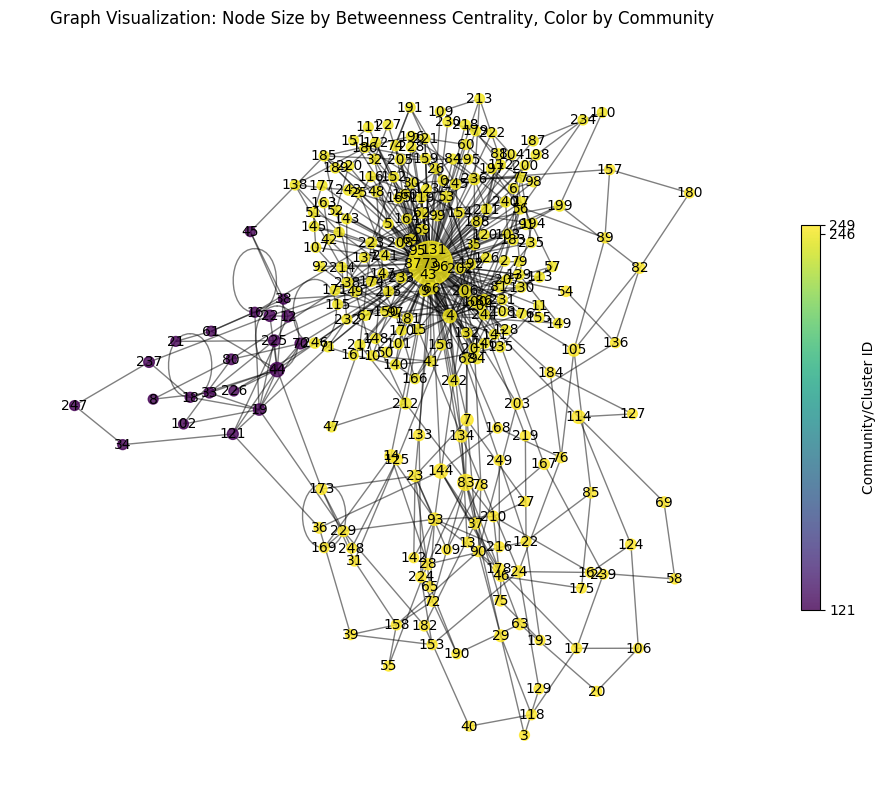

In [ ]:
def display_graph_with_attributes(G, communities):
    betweenness = nx.betweenness_centrality(G)

    sizes = np.array([betweenness[node] for node in G.nodes()])
    max_size = 1000
    min_size = 50
    node_sizes = min_size + sizes / sizes.max() * (max_size - min_size)

    community_labels = [communities[node] for node in G.nodes()]

    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(12, 10))

    node_collection = nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        node_color=community_labels,
        cmap=plt.cm.get_cmap('viridis'),
        alpha=0.8
    )

    nx.draw_networkx_edges(G, pos, alpha=0.5)

    nx.draw_networkx_labels(G, pos, font_size=10)

    plt.title("Graph Visualization: Node Size by Betweenness Centrality, Color by Community")
    plt.colorbar(
        node_collection,
        label="Community/Cluster ID",
        ticks=list(set(community_labels)),
        shrink=0.5
    )
    plt.axis('off')
    plt.show()

display_graph_with_attributes(G, ground_truth)